In [1]:
# ============================================================
# Step 1 - Import Libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import os
import zipfile
import time

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from sklearn.ensemble import IsolationForest

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Dense,
    BatchNormalization,
    Dropout
)

from tensorflow.keras.optimizers import Adam

print("TensorFlow Version:", tf.__version__)
print("Libraries Loaded Successfully")

TensorFlow Version: 2.20.0
Libraries Loaded Successfully


In [2]:
# ============================================================
# Step 2 - Mount Google Drive
# ============================================================

from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# ============================================================
# Step 3 - Check Google Drive Files
# ============================================================

import os

drive_path = "/content/drive/MyDrive"

for item in os.listdir(drive_path):
    print(item)

captions.txt
Colab Notebooks
Images.rar
LMD2023_Project


In [6]:
# ============================================================
# Step 4 - Check LMD2023 Project Folder
# ============================================================

import os

project_path = "/content/drive/MyDrive/LMD2023_Project"

for root, dirs, files in os.walk(project_path):

    print("\nPATH:", root)

    for f in files[:10]:
        print("   ", f)


PATH: /content/drive/MyDrive/LMD2023_Project
    archive.zip


In [7]:
# ============================================================
# Step 5 - Extract Dataset
# ============================================================

import zipfile
import os

zip_path = "/content/drive/MyDrive/LMD2023_Project/archive.zip"

extract_path = "/content/LMD2023"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction Completed Successfully")

Extraction Completed Successfully


In [8]:
# ============================================================
# Step 6 - Check Extracted Files
# ============================================================

import os

for root, dirs, files in os.walk("/content/LMD2023"):

    print("\nPATH:", root)

    for f in files[:10]:
        print("   ", f)


PATH: /content/LMD2023

PATH: /content/LMD2023/LMD-2023 1.75M Elements Checked
    LMD-2023 1.75M ElementsChecked.csv

PATH: /content/LMD2023/LMD-2023 1.75M Elements Checked/Labelled LMD-2023
    LMD-2023 1.75M Elements Labelled checked.csv

PATH: /content/LMD2023/LMD-2023 1.75M Elements Checked/Labelled LMD-2023/Labelled Subsets
    LMD-2023 1.75M Elements - EoRS checked.csv
    LMD-2023 1.75M Elements - EoHTchecked.csv
    LMD-2023 1.75M Elements - Normal checked.csv

PATH: /content/LMD2023/LMD-2023 1.75M Elements Checked/Preprocessed LMD-2023
    LMD-2023 1.75M Elements Labelled+Preprocessed.csv


In [9]:
# ============================================================
# Step 7 - Load LMD-2023 Preprocessed Dataset
# ============================================================

import pandas as pd

dataset_path = "/content/LMD2023/LMD-2023 1.75M Elements Checked/Preprocessed LMD-2023/LMD-2023 1.75M Elements Labelled+Preprocessed.csv"

df = pd.read_csv(dataset_path)

print("="*60)
print("Dataset Shape:", df.shape)
print("="*60)

display(df.head())

Dataset Shape: (1723308, 83)


,SystemTime,EventRecordID,Execution_ProcessID,ProcessId,Unnamed: 0.2,SystemTime_day,SystemTime_hour,SystemTime_minute,Label,EventID_0.0,...,SystemTime_week_47,SystemTime_week_48,SystemTime_week_49,SystemTime_day_of_week_0,SystemTime_day_of_week_1,SystemTime_day_of_week_2,SystemTime_day_of_week_3,SystemTime_day_of_week_4,SystemTime_day_of_week_5,SystemTime_day_of_week_6
0,2022-10-10 10:35:33.000000,0.000011,0.0,0.567183,0,0.269231,0.434783,0.593220,0,0,...,0,0,0,1,0,0,0,0,0,0
1,2022-10-10 10:35:49.417052,0.000011,0.0,0.567183,1,0.269231,0.434783,0.593220,0,0,...,0,0,0,1,0,0,0,0,0,0
2,2022-10-10 10:35:50.922113,0.000011,0.0,0.000156,2,0.269231,0.434783,0.593220,0,0,...,0,0,0,1,0,0,0,0,0,0
3,2022-10-10 10:36:07.534514,0.000011,0.0,0.000156,3,0.269231,0.434783,0.610169,0,0,...,0,0,0,1,0,0,0,0,0,0
4,2022-10-10 10:35:42.454330,0.000049,0.0,0.000000,4,0.269231,0.434783,0.593220,0,0,...,0,0,0,1,0,0,0,0,0,0


In [10]:
# ============================================================
# Step 8 - Label Distribution
# ============================================================

print(df["Label"].value_counts())

print("\nLabel Distribution:")
print(df["Label"].value_counts(normalize=True))

Label
0    1590361
1     106263
2      26684
Name: count, dtype: int64

Label Distribution:
Label
0    0.922854
1    0.061662
2    0.015484
Name: proportion, dtype: float64


In [11]:
# ============================================================
# Step 9 - Binary Label Conversion
# ============================================================

df["Label"] = df["Label"].apply(
    lambda x: 0 if x == 0 else 1
)

print(df["Label"].value_counts())

Label
0    1590361
1     132947
Name: count, dtype: int64


In [12]:
# ============================================================
# Step 10 - Features and Labels
# ============================================================

X = df.drop("Label", axis=1)

y = df["Label"]

print("="*60)
print("Feature Shape :", X.shape)
print("Label Shape   :", y.shape)
print("="*60)

Feature Shape : (1723308, 82)
Label Shape   : (1723308,)


In [13]:
# ============================================================
# Step 11 - Remove Unnecessary Features
# ============================================================

drop_cols = [
    "SystemTime",
    "Unnamed: 0.2"
]

for col in drop_cols:
    if col in X.columns:
        X = X.drop(columns=[col])

print("="*60)
print("New Feature Shape :", X.shape)
print("="*60)

New Feature Shape : (1723308, 80)


In [14]:
# ============================================================
# Step 12 - Train Test Split
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


print("="*60)
print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)
print("="*60)

print("\nTrain Labels:")
print(y_train.value_counts())

print("\nTest Labels:")
print(y_test.value_counts())

Training Set : (1292481, 80)
Testing Set  : (430827, 80)

Train Labels:
Label
0    1192771
1      99710
Name: count, dtype: int64

Test Labels:
Label
0    397590
1     33237
Name: count, dtype: int64


In [15]:
# ============================================================
# Step 13 - MinMax Scaling
# ============================================================

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)


print("="*60)
print("Scaled Train :", X_train.shape)
print("Scaled Test  :", X_test.shape)
print("="*60)

Scaled Train : (1292481, 80)
Scaled Test  : (430827, 80)


In [16]:
# ============================================================
# Step 14 - Normal Training Data
# ============================================================

X_train_normal = X_train[y_train.values == 0]

print("="*60)
print("Normal Training Samples :", X_train_normal.shape)
print("="*60)

Normal Training Samples : (1192771, 80)


In [20]:
# ============================================================
# Step 15 - Build Stacked Autoencoder
# ============================================================

import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Dense,
    BatchNormalization
)

from tensorflow.keras.optimizers import Adam


input_dim = X_train_normal.shape[1]


input_layer = Input(shape=(input_dim,))


# -------------------------
# Encoder
# -------------------------

x = Dense(50, activation="relu")(input_layer)
x = BatchNormalization()(x)

x = Dense(30, activation="relu")(x)
x = BatchNormalization()(x)

x = Dense(20, activation="relu")(x)

x = Dense(10, activation="relu")(x)

latent = Dense(5, activation="relu", name="latent")(x)


# -------------------------
# Decoder
# -------------------------

x = Dense(10, activation="relu")(latent)

x = Dense(20, activation="relu")(x)

x = Dense(30, activation="relu")(x)

x = Dense(50, activation="relu")(x)


output_layer = Dense(
    input_dim,
    activation="sigmoid"
)(x)


autoencoder = Model(
    input_layer,
    output_layer
)


autoencoder.compile(
    optimizer=Adam(
        learning_rate=1e-3
    ),
    loss="binary_crossentropy"
)


autoencoder.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 50)             │         4,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 50)             │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 30)             │         1,530 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 30)             │           120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 20)             │           620 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 10)             │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 20)             │           220 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 30)             │           630 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 50)             │         1,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 80)             │         4,080 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,325 (52.05 KB)

 Trainable params: 13,165 (51.43 KB)

 Non-trainable params: 160 (640.00 B)

In [21]:
# ============================================================
# Step 16 - Train Autoencoder
# ============================================================

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)


start_time = time.time()


history = autoencoder.fit(
    X_train_normal,
    X_train_normal,

    epochs=40,

    batch_size=50,

    validation_split=0.2,

    callbacks=[early_stop],

    shuffle=True,

    verbose=1
)


end_time = time.time()


print("="*60)
print(
    "Training Time:",
    round((end_time-start_time)/60,2),
    "minutes"
)
print("="*60)

Epoch 1/40
19085/19085 ━━━━━━━━━━━━━━━━━━━━ 79s 4ms/step - loss: 0.0468 - val_loss: 0.0290
Epoch 2/40
19085/19085 ━━━━━━━━━━━━━━━━━━━━ 72s 4ms/step - loss: 0.0294 - val_loss: 0.0286
Epoch 3/40
19085/19085 ━━━━━━━━━━━━━━━━━━━━ 72s 4ms/step - loss: 0.0287 - val_loss: 0.0280
Epoch 4/40
19085/19085 ━━━━━━━━━━━━━━━━━━━━ 71s 4ms/step - loss: 0.0279 - val_loss: 0.0266
Epoch 5/40
19085/19085 ━━━━━━━━━━━━━━━━━━━━ 71s 4ms/step - loss: 0.0272 - val_loss: 0.0263
Epoch 6/40
19085/19085 ━━━━━━━━━━━━━━━━━━━━ 71s 4ms/step - loss: 0.0269 - val_loss: 0.0264
Epoch 7/40
19085/19085 ━━━━━━━━━━━━━━━━━━━━ 71s 4ms/step - loss: 0.0267 - val_loss: 0.0260
Epoch 8/40
19085/19085 ━━━━━━━━━━━━━━━━━━━━ 71s 4ms/step - loss: 0.0266 - val_loss: 0.0259
Epoch 9/40
19085/19085 ━━━━━━━━━━━━━━━━━━━━ 72s 4ms/step - loss: 0.0265 - val_loss: 0.0261
Epoch 10/40
19085/19085 ━━━━━━━━━━━━━━━━━━━━ 71s 4ms/step - loss: 0.0264 - val_loss: 0.0260
Epoch 11/40
19085/19085 ━━━━━━━━━━━━━━━━━━━━ 82s 4ms/step - loss: 0.0263 - val_loss: 0.02

In [22]:
# ============================================================
# Step 17 - Build Encoder Model
# ============================================================

from tensorflow.keras.models import Model

encoder = Model(
    inputs=autoencoder.input,
    outputs=autoencoder.get_layer("latent").output
)

print("Encoder created successfully")

print("Latent dimension:",
      encoder.output_shape)

Encoder created successfully
Latent dimension: (None, 5)


In [23]:
# ============================================================
# Step 18 - Extract Normal Latent Features
# ============================================================

X_train_normal_latent = encoder.predict(
    X_train_normal,
    batch_size=256,
    verbose=1
)

print("="*60)
print("Latent Feature Shape:",
      X_train_normal_latent.shape)
print("="*60)

4660/4660 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step
Latent Feature Shape: (1192771, 5)


In [24]:
# ============================================================
# Step 19 - Normal Reconstruction
# ============================================================

X_train_normal_rec = autoencoder.predict(
    X_train_normal,
    batch_size=256,
    verbose=1
)


print("="*60)
print("Original Shape:",
      X_train_normal.shape)

print("Reconstructed Shape:",
      X_train_normal_rec.shape)

print("="*60)

4660/4660 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step
Original Shape: (1192771, 80)
Reconstructed Shape: (1192771, 80)


In [25]:
# ============================================================
# Step 20 - Reconstruction Error
# ============================================================

normal_error = np.mean(
    np.square(
        X_train_normal - X_train_normal_rec
    ),
    axis=1
)


print("="*60)

print("Mean Error:",
      np.mean(normal_error))

print("Max Error:",
      np.max(normal_error))

print("="*60)

Mean Error: 0.0012298927190679703
Max Error: 0.22164339565768937


In [26]:
# ============================================================
# Step 21 - Build Stage2 Normal Data
# ============================================================


normal_error_column = normal_error.reshape(-1,1)


X_stage2_normal = np.hstack([
    X_train_normal_latent,
    normal_error_column
])


print("="*60)
print("Stage2 Normal Shape :", X_stage2_normal.shape)
print("="*60)

Stage2 Normal Shape : (1192771, 6)


In [27]:
# ============================================================
# Step 22 - Prepare Attack Training Data
# ============================================================

X_train_attack = X_train[y_train.values == 1]


print("="*60)
print("Attack Training Shape :", X_train_attack.shape)
print("="*60)

Attack Training Shape : (99710, 80)


In [28]:
# ============================================================
# Step 23 - Attack Latent + Reconstruction
# ============================================================

# Latent features
X_train_attack_latent = encoder.predict(
    X_train_attack,
    batch_size=256,
    verbose=1
)


# Reconstruction
X_train_attack_rec = autoencoder.predict(
    X_train_attack,
    batch_size=256,
    verbose=1
)


print("="*60)
print("Attack Latent Shape :", X_train_attack_latent.shape)
print("Attack Reconstruction Shape :", X_train_attack_rec.shape)
print("="*60)

390/390 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
390/390 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Attack Latent Shape : (99710, 5)
Attack Reconstruction Shape : (99710, 80)


In [29]:
# ============================================================
# Step 24 - Attack Reconstruction Error
# ============================================================

attack_error = np.mean(
    np.square(
        X_train_attack - X_train_attack_rec
    ),
    axis=1
)


print("="*60)
print("Attack Mean Error :", np.mean(attack_error))
print("Attack Max Error  :", np.max(attack_error))
print("="*60)

Attack Mean Error : 0.13107698452547828
Attack Max Error  : 0.2330777733024992


In [30]:
# ============================================================
# Step 25 - Build Attack Stage2 Data
# ============================================================

attack_error_column = attack_error.reshape(-1,1)


X_stage2_attack = np.hstack([
    X_train_attack_latent,
    attack_error_column
])


print("="*60)

print("Normal Stage2 :", X_stage2_normal.shape)

print("Attack Stage2 :", X_stage2_attack.shape)

print("="*60)

Normal Stage2 : (1192771, 6)
Attack Stage2 : (99710, 6)


In [31]:
# ============================================================
# Step 26 - Final Stage2 Training Data
# ============================================================

X_stage2 = np.vstack([
    X_stage2_normal,
    X_stage2_attack
])


y_stage2 = np.hstack([
    np.zeros(len(X_stage2_normal)),
    np.ones(len(X_stage2_attack))
])


print("="*60)

print("Stage2 Shape :", X_stage2.shape)

print("Labels Shape :", y_stage2.shape)

print("Normal :", np.sum(y_stage2==0))

print("Attack :", np.sum(y_stage2==1))

print("="*60)

Stage2 Shape : (1292481, 6)
Labels Shape : (1292481,)
Normal : 1192771
Attack : 99710


In [32]:
# ============================================================
# Step 27 - Train Isolation Forest
# ============================================================

from sklearn.ensemble import IsolationForest
import time


start = time.time()


iso = IsolationForest(
    n_estimators=100,
    contamination=0.08,
    random_state=42,
    n_jobs=-1
)


iso.fit(X_stage2)


end = time.time()


print("="*60)
print("Isolation Forest Trained Successfully")
print(
    "Training Time:",
    round((end-start)/60,2),
    "minutes"
)
print("="*60)

Isolation Forest Trained Successfully
Training Time: 0.15 minutes


In [33]:
# ============================================================
# Step 28 - Test Latent + Reconstruction
# ============================================================

# Latent Features
X_test_latent = encoder.predict(
    X_test,
    batch_size=256,
    verbose=1
)


# Reconstruction
X_test_rec = autoencoder.predict(
    X_test,
    batch_size=256,
    verbose=1
)


print("="*60)
print("Test Latent Shape :", X_test_latent.shape)
print("Test Reconstruction Shape :", X_test_rec.shape)
print("="*60)

1683/1683 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1683/1683 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
Test Latent Shape : (430827, 5)
Test Reconstruction Shape : (430827, 80)


In [34]:
# ============================================================
# Step 29 - Test Reconstruction Error
# ============================================================

test_error = np.mean(
    np.square(
        X_test - X_test_rec
    ),
    axis=1
)


print("="*60)

print("Mean Test Error :", np.mean(test_error))

print("Max Test Error :", np.max(test_error))

print("="*60)

Mean Test Error : 0.011251879437872637
Max Test Error : 0.23286486366978165


In [35]:
# ============================================================
# Step 30 - Build Test Stage2 Data
# ============================================================

test_error_column = test_error.reshape(-1,1)


X_test_stage2 = np.hstack([
    X_test_latent,
    test_error_column
])


print("="*60)
print("Test Stage2 Shape :", X_test_stage2.shape)
print("="*60)

Test Stage2 Shape : (430827, 6)


In [36]:
# ============================================================
# Step 31 - Isolation Forest Prediction
# ============================================================

start = time.time()


iso_pred = iso.predict(
    X_test_stage2
)


end = time.time()


# Isolation Forest:
# 1  = normal
# -1 = anomaly

y_pred = np.where(
    iso_pred == -1,
    1,
    0
)


print("="*60)

print("Prediction Finished")

print("Predicted Normal:",
      np.sum(y_pred==0))

print("Predicted Attack:",
      np.sum(y_pred==1))

print("Prediction Time:",
      round(end-start,2),
      "seconds")

print("="*60)

Prediction Finished
Predicted Normal: 396373
Predicted Attack: 34454
Prediction Time: 2.31 seconds


In [37]:
# ============================================================
# Step 32 - Evaluation Metrics
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)


accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)


print("="*60)

print("Accuracy :", accuracy)

print("Precision:", precision)

print("Recall   :", recall)

print("F1-score :", f1)

print("="*60)


print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)

Accuracy : 0.9074361634716487
Precision: 0.4036106112497823
Recall   : 0.41838914462797483
F1-score : 0.4108670281130431

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95    397590
           1       0.40      0.42      0.41     33237

    accuracy                           0.91    430827
   macro avg       0.68      0.68      0.68    430827
weighted avg       0.91      0.91      0.91    430827



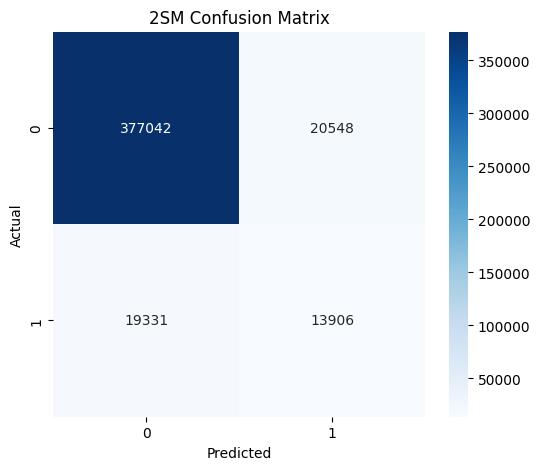

In [38]:
# ============================================================
# Step 33 - Confusion Matrix
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns


cm = confusion_matrix(
    y_test,
    y_pred
)


plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("2SM Confusion Matrix")

plt.show()

In [39]:
# ============================================================
# Step 34 - Try Different Contamination Values
# ============================================================

for contamination in [0.10, 0.12, 0.15]:

    print("="*60)
    print("Contamination:", contamination)

    iso_test = IsolationForest(
        n_estimators=100,
        contamination=contamination,
        random_state=42,
        n_jobs=-1
    )

    iso_test.fit(X_stage2)


    pred = iso_test.predict(X_test_stage2)

    pred = np.where(
        pred == -1,
        1,
        0
    )


    print("Accuracy:",
          accuracy_score(y_test,pred))

    print("Precision:",
          precision_score(y_test,pred))

    print("Recall:",
          recall_score(y_test,pred))

    print("F1:",
          f1_score(y_test,pred))

Contamination: 0.1
Accuracy: 0.9065332488446639
Precision: 0.418280294753481
Recall: 0.5413846014983301
F1: 0.4719366344943349
Contamination: 0.12
Accuracy: 0.8990406822227948
Precision: 0.401057037594275
Recall: 0.6255678912055841
F1: 0.4887635166901739
Contamination: 0.15
Accuracy: 0.8850025648346088
Precision: 0.37384536832170323
Recall: 0.7269609170502753
F1: 0.4937671148894429


In [40]:
# ============================================================
# Step 35 - Final Isolation Forest Model
# ============================================================

iso_final = IsolationForest(
    n_estimators=100,
    contamination=0.15,
    random_state=42,
    n_jobs=-1
)

iso_final.fit(X_stage2)


final_pred = iso_final.predict(
    X_test_stage2
)

final_pred = np.where(
    final_pred == -1,
    1,
    0
)


print("="*60)
print("Final Prediction Finished")

print("Normal:",
      np.sum(final_pred==0))

print("Attack:",
      np.sum(final_pred==1))

print("="*60)

Final Prediction Finished
Normal: 366196
Attack: 64631


In [41]:
# ============================================================
# Step 36 - Final Evaluation
# ============================================================

print("="*60)

print("Accuracy:",
      accuracy_score(y_test, final_pred))

print("Precision:",
      precision_score(y_test, final_pred))

print("Recall:",
      recall_score(y_test, final_pred))

print("F1-Score:",
      f1_score(y_test, final_pred))

print("="*60)


print(
    classification_report(
        y_test,
        final_pred
    )
)

Accuracy: 0.8850025648346088
Precision: 0.37384536832170323
Recall: 0.7269609170502753
F1-Score: 0.4937671148894429
              precision    recall  f1-score   support

           0       0.98      0.90      0.94    397590
           1       0.37      0.73      0.49     33237

    accuracy                           0.89    430827
   macro avg       0.67      0.81      0.71    430827
weighted avg       0.93      0.89      0.90    430827



[[357121  40469]
 [  9075  24162]]


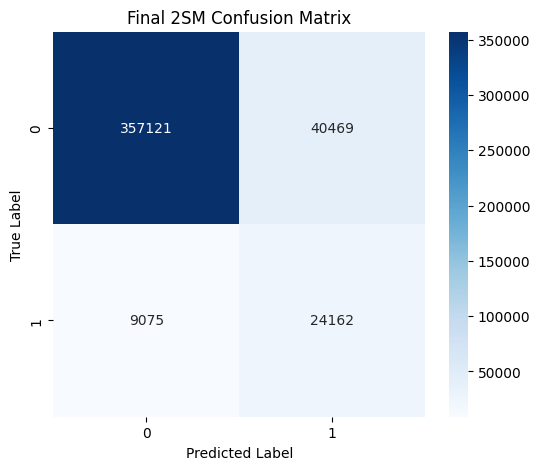

In [42]:
# ============================================================
# Step 37 - Final Confusion Matrix
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_final = confusion_matrix(
    y_test,
    final_pred
)

print(cm_final)


plt.figure(figsize=(6,5))

sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Final 2SM Confusion Matrix")

plt.show()

ROC-AUC: 0.9345363377456556


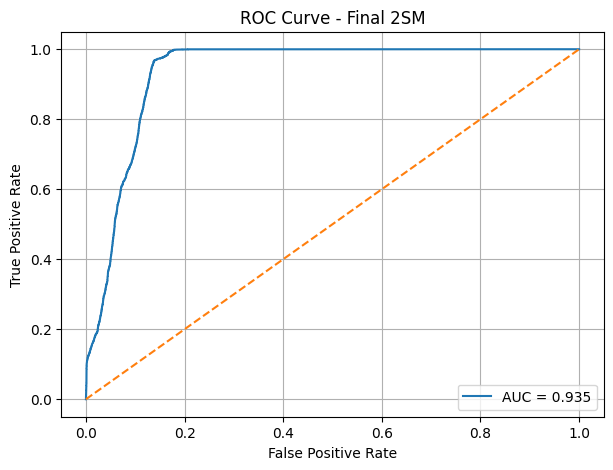

In [43]:
# ============================================================
# Step 38 - ROC AUC
# ============================================================

from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt


# Isolation Forest score
scores = -iso_final.decision_function(X_test_stage2)


auc = roc_auc_score(
    y_test,
    scores
)

print("ROC-AUC:", auc)


fpr, tpr, thresholds = roc_curve(
    y_test,
    scores
)


plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final 2SM")
plt.legend()
plt.grid()

plt.show()

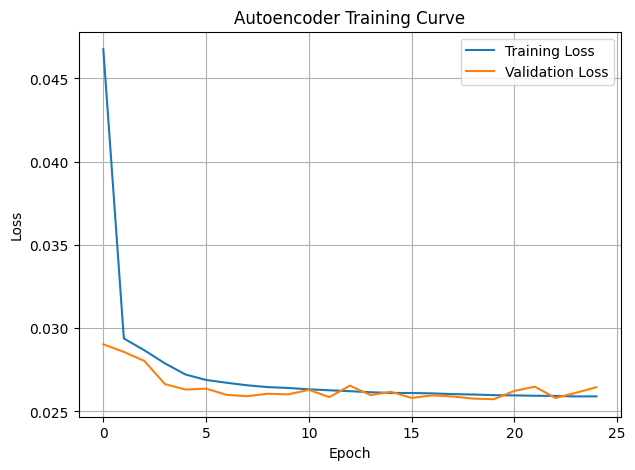

In [44]:
# ============================================================
# Autoencoder Training Loss Curve
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Autoencoder Training Curve")

plt.legend()
plt.grid()

plt.show()

In [45]:
# ============================================================
# Final Results Table
# ============================================================

results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],

    "Value": [
        accuracy_score(y_test, final_pred),
        precision_score(y_test, final_pred),
        recall_score(y_test, final_pred),
        f1_score(y_test, final_pred),
        auc
    ]
})


results

,Metric,Value
0,Accuracy,0.885003
1,Precision,0.373845
2,Recall,0.726961
3,F1-score,0.493767
4,ROC-AUC,0.934536


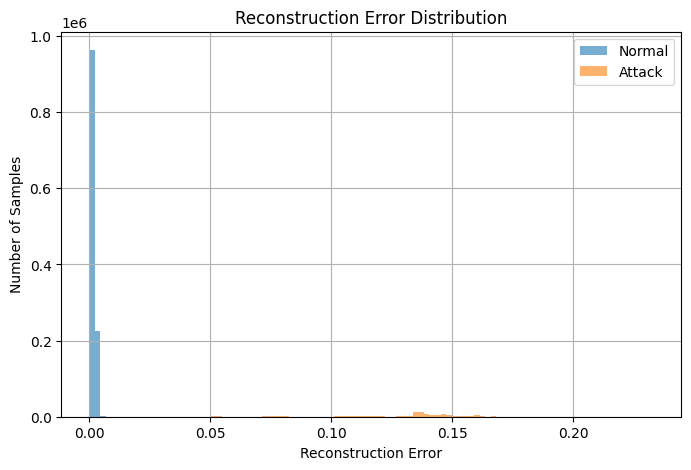

In [46]:
# ============================================================
# Reconstruction Error Distribution
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    normal_error,
    bins=100,
    alpha=0.6,
    label="Normal"
)

plt.hist(
    attack_error,
    bins=100,
    alpha=0.6,
    label="Attack"
)

plt.xlabel("Reconstruction Error")
plt.ylabel("Number of Samples")
plt.title("Reconstruction Error Distribution")

plt.legend()
plt.grid()

plt.show()

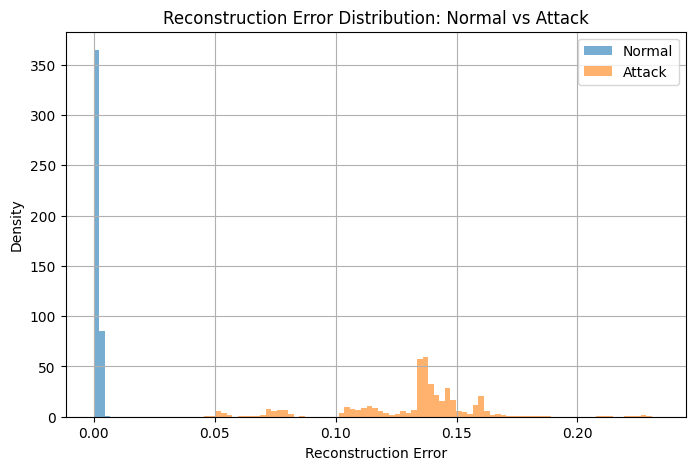

In [47]:
# ============================================================
# Better Reconstruction Error Distribution
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    normal_error,
    bins=100,
    density=True,
    alpha=0.6,
    label="Normal"
)

plt.hist(
    attack_error,
    bins=100,
    density=True,
    alpha=0.6,
    label="Attack"
)


plt.xlabel("Reconstruction Error")
plt.ylabel("Density")

plt.title(
    "Reconstruction Error Distribution: Normal vs Attack"
)

plt.legend()
plt.grid()

plt.show()

In [48]:
# ============================================================
# Dataset Statistics
# ============================================================

print("="*60)
print("Dataset Statistics")
print("="*60)

print("Total Samples :", len(df))

print("\nFeature Count :", X.shape[1])

print("\nClass Distribution:")
print(df["Label"].value_counts())

print("\nNormal Percentage:",
      round((sum(df["Label"]==0)/len(df))*100,2))

print("Attack Percentage:",
      round((sum(df["Label"]==1)/len(df))*100,2))

print("="*60)

Dataset Statistics
Total Samples : 1723308

Feature Count : 80

Class Distribution:
Label
0    1590361
1     132947
Name: count, dtype: int64

Normal Percentage: 92.29
Attack Percentage: 7.71


In [49]:
# ============================================================
# Autoencoder Configuration
# ============================================================

print("="*60)
print("Autoencoder Configuration")
print("="*60)

print("Input Dimension :", input_dim)
print("Latent Dimension :", encoder.output_shape[1])

print("\nArchitecture:")
print("80 -> 50 -> 30 -> 20 -> 10 -> 5 -> 10 -> 20 -> 30 -> 50 -> 80")

print("\nOptimizer: Adam")
print("Loss: Binary Crossentropy")
print("Learning Rate: 0.001")
print("Batch Size: 50")
print("Maximum Epochs: 40")

print("="*60)

Autoencoder Configuration
Input Dimension : 80
Latent Dimension : 5

Architecture:
80 -> 50 -> 30 -> 20 -> 10 -> 5 -> 10 -> 20 -> 30 -> 50 -> 80

Optimizer: Adam
Loss: Binary Crossentropy
Learning Rate: 0.001
Batch Size: 50
Maximum Epochs: 40


In [50]:
# ============================================================
# Reconstruction Error Statistics
# ============================================================

print("="*60)
print("Reconstruction Error Statistics")
print("="*60)

print("Normal Mean Error:",
      np.mean(normal_error))

print("Normal Median Error:",
      np.median(normal_error))

print("Attack Mean Error:",
      np.mean(attack_error))

print("Attack Median Error:",
      np.median(attack_error))

print("="*60)

Reconstruction Error Statistics
Normal Mean Error: 0.0012298927190679703
Normal Median Error: 0.0009128284520588687
Attack Mean Error: 0.13107698452547828
Attack Median Error: 0.13688185520882362


In [51]:
# ============================================================
# Isolation Forest Configuration
# ============================================================

print("="*60)
print("Isolation Forest Configuration")
print("="*60)

print("Number of Trees :", 100)
print("Contamination :", 0.15)
print("Random State :", 42)

print("Input Features :", X_stage2.shape[1])

print("="*60)

Isolation Forest Configuration
Number of Trees : 100
Contamination : 0.15
Random State : 42
Input Features : 6


In [52]:
# ============================================================
# Final Result Summary
# ============================================================

summary = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],

    "Value":[
        accuracy_score(y_test, final_pred),
        precision_score(y_test, final_pred),
        recall_score(y_test, final_pred),
        f1_score(y_test, final_pred),
        auc
    ]

})


print(summary)

      Metric     Value
0   Accuracy  0.885003
1  Precision  0.373845
2     Recall  0.726961
3   F1-score  0.493767
4    ROC-AUC  0.934536


In [53]:
# ============================================================
# Model Parameters
# ============================================================

print("="*60)
print("Autoencoder Parameters")
print("="*60)

autoencoder.summary()

Autoencoder Parameters


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 50)             │         4,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 50)             │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 30)             │         1,530 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 30)             │           120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 20)             │           620 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 10)             │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 20)             │           220 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 30)             │           630 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 50)             │         1,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 80)             │         4,080 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,657 (154.91 KB)

 Trainable params: 13,165 (51.43 KB)

 Non-trainable params: 160 (640.00 B)

 Optimizer params: 26,332 (102.86 KB)

In [54]:
# ============================================================
# Reconstruction Error Comparison
# ============================================================

comparison = pd.DataFrame({

    "Class":[
        "Normal",
        "Attack"
    ],

    "Mean Reconstruction Error":[
        np.mean(normal_error),
        np.mean(attack_error)
    ],

    "Median Reconstruction Error":[
        np.median(normal_error),
        np.median(attack_error)
    ],

    "Maximum Error":[
        np.max(normal_error),
        np.max(attack_error)
    ]

})

comparison

,Class,Mean Reconstruction Error,Median Reconstruction Error,Maximum Error
0,Normal,0.001230,0.000913,0.221643
1,Attack,0.131077,0.136882,0.233078


In [55]:
# ============================================================
# Prediction Statistics
# ============================================================

cm = confusion_matrix(
    y_test,
    final_pred
)

TN, FP, FN, TP = cm.ravel()

print("="*60)

print("True Negative :", TN)
print("False Positive:", FP)
print("False Negative:", FN)
print("True Positive :", TP)

print("="*60)

True Negative : 357121
False Positive: 40469
False Negative: 9075
True Positive : 24162


In [56]:
# ============================================================
# Detection Rates
# ============================================================

attack_detection_rate = TP/(TP+FN)

false_alarm_rate = FP/(FP+TN)


print("="*60)

print(
    "Attack Detection Rate (Recall):",
    attack_detection_rate
)

print(
    "False Alarm Rate:",
    false_alarm_rate
)

print("="*60)

Attack Detection Rate (Recall): 0.7269609170502753
False Alarm Rate: 0.10178575919917503


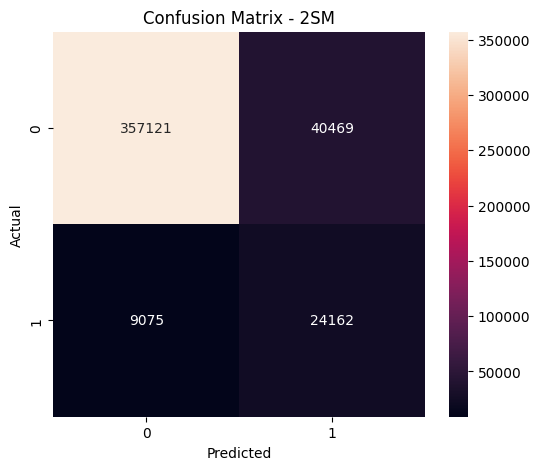

In [57]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - 2SM")

plt.savefig(
    "Confusion_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

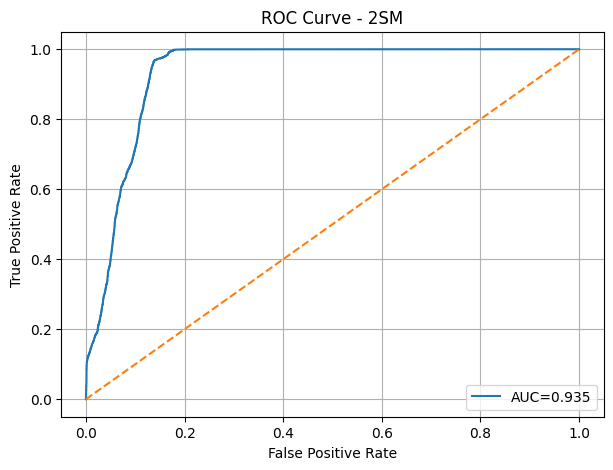

In [58]:
plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC={auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - 2SM")

plt.legend()
plt.grid()

plt.savefig(
    "ROC_Curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

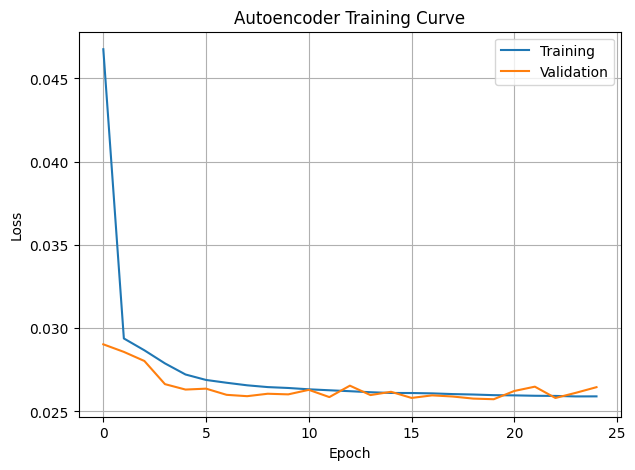

In [59]:
plt.figure(figsize=(7,5))

plt.plot(history.history["loss"],
         label="Training")

plt.plot(history.history["val_loss"],
         label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Autoencoder Training Curve")

plt.legend()
plt.grid()

plt.savefig(
    "Training_Curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [60]:
# ============================================================
# Baseline Model - Isolation Forest on Raw Features
# ============================================================

from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import time


start = time.time()


iso_baseline = IsolationForest(
    n_estimators=100,
    contamination=0.15,
    random_state=42,
    n_jobs=-1
)


iso_baseline.fit(X_train)


baseline_pred = iso_baseline.predict(X_test)


baseline_pred = np.where(
    baseline_pred == -1,
    1,
    0
)


end = time.time()


print("="*60)
print("Baseline Isolation Forest Results")
print("="*60)


print("Accuracy:",
      accuracy_score(y_test, baseline_pred))

print("Precision:",
      precision_score(y_test, baseline_pred))

print("Recall:",
      recall_score(y_test, baseline_pred))

print("F1-score:",
      f1_score(y_test, baseline_pred))


print("Time:",
      round(end-start,2),
      "seconds")

print("="*60)

Baseline Isolation Forest Results
Accuracy: 0.8904920072326015
Precision: 0.39267459046680625
Recall: 0.7673676926317057
F1-score: 0.5195082952265528
Time: 18.42 seconds
